In [ ]:
#Installare Prophet e importare librerie
!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Prophet installato e pronto")

Prophet installato e pronto


In [ ]:
# Caricamento dati e preparazione serie storica

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('lecce_turismo_pulito.csv')

# Aggregazione provinciale per anno
df_provincia = df.groupby('anno').agg(
    arrivi_totali   = ('arr_tot_tot', 'sum'),
    presenze_totali = ('pre_tot_tot', 'sum'),
).reset_index()

# Prophet vuole colonne chiamate 'ds' e 'y'
# ds = data, y = valore da prevedere
# Usiamo il 1 luglio come data rappresentativa dell'anno turistico
df_prophet = pd.DataFrame({
    'ds': pd.to_datetime(df_provincia['anno'].astype(str) + '-07-01'),
    'y' : df_provincia['arrivi_totali']
})

print(df_prophet)

Saving lecce_turismo_pulito.csv to lecce_turismo_pulito.csv
           ds          y
0  2014-07-01   863435.0
1  2015-07-01   914947.0
2  2016-07-01  1012322.0
3  2017-07-01  1077532.0
4  2018-07-01  1075975.0
5  2019-07-01  1079816.0
6  2020-07-01   696069.0
7  2021-07-01   960540.0
8  2022-07-01  1177967.0
9  2023-07-01  1280786.0
10 2024-07-01  1351834.0


In [ ]:
# Gestione Covid e addestramento modello
# Definiamo il 2020 come evento straordinario (lockdown)
# Prophet ha uno strumento apposito per questo: i "regressori" o gli "holidays"
covid = pd.DataFrame({
    'holiday'   : 'covid_lockdown',
    'ds'        : pd.to_datetime(['2020-07-01']),
    'lower_window': 0,
    'upper_window': 0,
})

# Costruiamo il modello
modello = Prophet(
    holidays        = covid,
    yearly_seasonality = False,  # dati annuali, non mensili
    weekly_seasonality = False,
    daily_seasonality  = False,
    changepoint_prior_scale = 0.3,  # flessibilità nel rilevare trend
    interval_width  = 0.90          # intervallo di confidenza 90%
)

# Addestriamo
modello.fit(df_prophet)
print("Modello addestrato correttamente")

INFO:prophet:n_changepoints greater than number of observations. Using 7.


Modello addestrato correttamente


In [ ]:
# Previsione 2025-2028
# Creiamo le date future (2025, 2026, 2027, 2028)
futuro = modello.make_future_dataframe(periods=4, freq='AS-JUL')

# Previsione
forecast = modello.predict(futuro)

# Mostriamo solo i valori chiave
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(forecast[cols].tail(8).to_string(index=False))

        ds         yhat   yhat_lower   yhat_upper
2021-07-01 1.016295e+06 9.756358e+05 1.055023e+06
2022-07-01 1.136391e+06 1.096859e+06 1.176506e+06
2023-07-01 1.256487e+06 1.216578e+06 1.298202e+06
2024-07-01 1.376912e+06 1.338695e+06 1.417439e+06
2025-07-01 1.497008e+06 1.444896e+06 1.544736e+06
2026-07-01 1.617104e+06 1.506594e+06 1.724104e+06
2027-07-01 1.737200e+06 1.517772e+06 1.930925e+06
2028-07-01 1.857625e+06 1.535204e+06 2.154353e+06


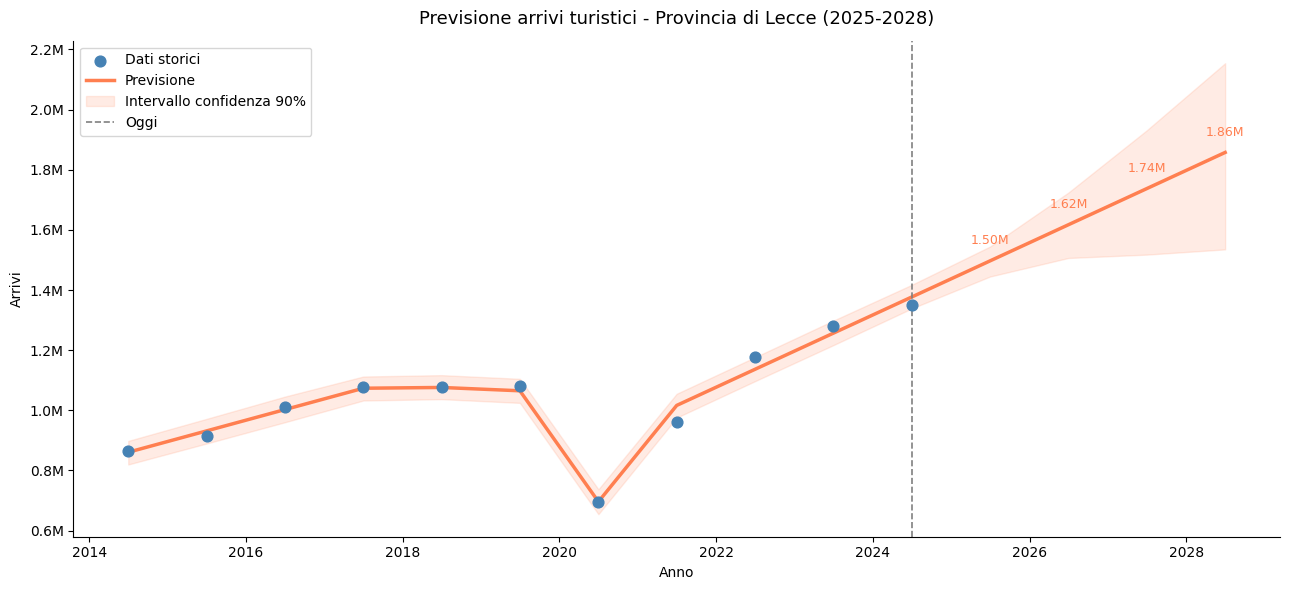

In [ ]:
#Grafico previsione Prophet
fig, ax = plt.subplots(figsize=(13, 6))

# Dati storici
ax.scatter(df_prophet['ds'], df_prophet['y'],
           color='steelblue', zorder=5, s=60, label='Dati storici')

# Linea previsione
ax.plot(forecast['ds'], forecast['yhat'],
        color='coral', linewidth=2.5, label='Previsione')

# Banda di confidenza
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                color='coral', alpha=0.15, label='Intervallo confidenza 90%')

# Linea verticale che separa storico da futuro
ax.axvline(pd.to_datetime('2024-07-01'),
           color='gray', linestyle='--', linewidth=1.2, label='Oggi')

# Annotazioni anni futuri
for _, row in forecast[forecast['ds'] >= '2025-01-01'].iterrows():
    ax.annotate(f"{row['yhat']/1e6:.2f}M",
                xy=(row['ds'], row['yhat']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, color='coral')

ax.set_title('Previsione arrivi turistici - Provincia di Lecce (2025-2028)',
             fontsize=13, pad=12)
ax.set_xlabel('Anno')
ax.set_ylabel('Arrivi')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('forecasting_arrivi.png', dpi=150, bbox_inches='tight')
plt.show()

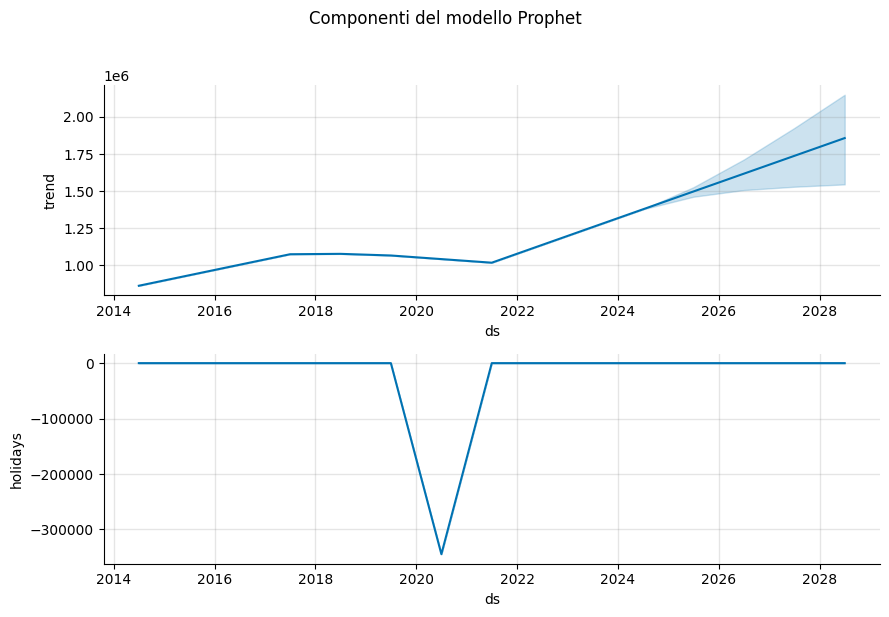

In [ ]:
#Grafico componenti del modello
fig = modello.plot_components(forecast)
plt.suptitle('Componenti del modello Prophet', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('prophet_componenti.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tabella riassuntiva previsioni leggibile
# Tabella pulita con i valori futuri
previsioni = forecast[forecast['ds'] >= '2025-01-01'][
    ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
].copy()

previsioni['Anno']     = previsioni['ds'].dt.year
previsioni['Arrivi previsti'] = previsioni['yhat'].round(0).astype(int)
previsioni['Scenario pessimista'] = previsioni['yhat_lower'].round(0).astype(int)
previsioni['Scenario ottimista']  = previsioni['yhat_upper'].round(0).astype(int)
previsioni['Crescita vs 2024'] = (
    (previsioni['yhat'] / df_prophet['y'].iloc[-1] - 1) * 100
).round(1).astype(str) + '%'

print(previsioni[['Anno', 'Arrivi previsti',
                   'Scenario pessimista', 'Scenario ottimista',
                   'Crescita vs 2024']].to_string(index=False))

 Anno  Arrivi previsti  Scenario pessimista  Scenario ottimista Crescita vs 2024
 2025          1497008              1444896             1544736            10.7%
 2026          1617104              1506594             1724104            19.6%
 2027          1737200              1517772             1930925            28.5%
 2028          1857625              1535204             2154353            37.4%


In [ ]:
# Commento finale
# ============================================================
# NOTEBOOK 3 - FORECASTING CON PROPHET
# ============================================================
# Modello: Facebook Prophet con gestione evento Covid 2020
# Target: Arrivi turistici totali - Provincia di Lecce
# Periodo storico: 2014-2024 (11 osservazioni annuali)
# Orizzonte previsione: 2025-2028
# Intervallo di confidenza: 90%
#
# Risultati:
# - Trend di crescita strutturale confermato
# - Impatto Covid 2020 quantificato in circa -350.000 arrivi
# - Previsione 2025: ~1.5M arrivi (+10% vs 2024)
# - Previsione 2028: ~1.86M arrivi (+38% vs 2024)
# ============================================================

print("Forecasting completato. Pronti per il Notebook 4 - Insight Business")

Forecasting completato. Pronti per il Notebook 4 - Insight Business
